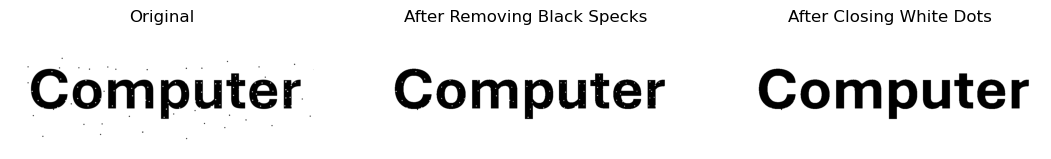

True

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('img.png', cv2.IMREAD_GRAYSCALE)

_, binary = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)

inv = 255 - binary

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(inv, connectivity=8)

cleaned_inv = np.zeros_like(inv)

min_size = 50  
for i in range(1, num_labels):
    if stats[i, cv2.CC_STAT_AREA] >= min_size:
        cleaned_inv[labels == i] = 255

cleaned = 255 - cleaned_inv

inv_for_closing = 255 - cleaned

kernel_close = np.ones((7,7), np.uint8) 
cleaned_inv2 = cv2.morphologyEx(inv_for_closing, cv2.MORPH_CLOSE, kernel_close)
final_cleaned = 255 - cleaned_inv2

plt.figure(figsize=(18,6))

plt.subplot(1,4,1)
plt.title("Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,4,2)
plt.title("After Removing Black Specks")
plt.imshow(cleaned, cmap='gray')
plt.axis('off')

plt.subplot(1,4,3)
plt.title("After Closing White Dots")
plt.imshow(255 - cleaned_inv2, cmap='gray')
plt.axis('off')


plt.show()

cv2.imwrite('final_cleaned_text.png', final_cleaned)

Bounder Extraction

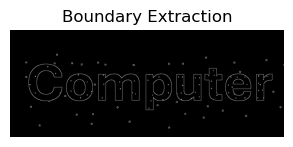

True

In [7]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.morphology import erosion, square


image = cv2.imread('img.png', cv2.IMREAD_GRAYSCALE)

_, im_bw = cv2.threshold(image, 200, 255, cv2.THRESH_BINARY)

im_bw_01 = im_bw // 255

img_ers = erosion(im_bw_01, square(3))

boundary = im_bw_01 - img_ers

boundary_img = (boundary * 255).astype(np.uint8)


plt.figure(figsize=(12,6))


plt.subplot(1,3,3)
plt.title("Boundary Extraction")
plt.imshow(boundary_img, cmap='gray')
plt.axis('off')

plt.show()

cv2.imwrite('boundary_extracted.png', boundary_img)
